# WM-811K Wafer Map Defect Classification — Model 4

Multi-scale feature extraction from a pre-trained ResNet34 backbone with Squeeze-and-Excitation attention gates at each stage, fused across four spatial resolutions for wafer defect classification.

## 1. Setup

In [88]:
import os, sys, time, copy, math, random, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA RTX A1000 Laptop GPU


## 2. Configuration

In [89]:
CFG = {
    'data_path':    './Data/LSWMD.pkl',
    'output_dir':   './outputs_model4',
    'image_size':   64,
    'batch_size':   64,
    'epochs':       50,
    'lr':           1e-4,
    'lr_backbone':  5e-6,
    'weight_decay': 1e-4,
    'dropout':      0.4,
    'grad_clip':    1.0,
    'patience':     8,
    'seed':         42,
    'num_workers':  0,
    'mixed_prec':   False,
    'loss_name':    'weighted_ce',
    'label_smooth': 0.0,
    'freeze_backbone_epochs': 3,
    'use_weighted_sampler': False,
    'use_imagenet_norm': True,
    'train_ratio':  0.60,
    'val_ratio':    0.20,
    'test_ratio':   0.20,
}

assert abs(CFG['train_ratio'] + CFG['val_ratio'] + CFG['test_ratio'] - 1.0) < 1e-9
print('Backbone LR:', CFG['lr_backbone'], '| Head LR:', CFG['lr'], '| Loss:', CFG['loss_name'])

Backbone LR: 5e-06 | Head LR: 0.0001 | Loss: weighted_ce


## 3. Reproducibility

In [90]:
def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])
print('Seed:', CFG['seed'])

Seed: 42


## 4. Data Loading

In [91]:
_compat = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}
for old, new in _compat.items():
    try: sys.modules[old] = __import__(new, fromlist=[''])
    except Exception: pass

class _Unpickler(pickle.Unpickler):
    def find_class(self, mod, name):
        for old, new in _compat.items():
            if mod.startswith(old):
                mod = mod.replace(old, new, 1); break
        return super().find_class(mod, name)

def load_pkl(path):
    with open(path, 'rb') as f:
        try: return pickle.load(f, encoding='latin1')
        except Exception:
            f.seek(0); u = _Unpickler(f); u.encoding = 'latin1'; return u.load()

def _find_col(cands, cols):
    lmap = {c.lower(): c for c in cols}
    for c in cands:
        if c.lower() in lmap: return lmap[c.lower()]
    return None

raw = load_pkl(CFG['data_path'])
df  = raw if isinstance(raw, pd.DataFrame) else pd.DataFrame(raw)

wmap_col  = _find_col(['waferMap', 'wafer_map', 'map', 'image'], df.columns)
label_col = _find_col(['failureType', 'failure_type', 'label', 'class', 'target'], df.columns)
print(f'wafer col: {wmap_col}  |  label col: {label_col}')
print('Shape:', df.shape)

def _extract(x):
    if isinstance(x, str): return x.strip() or 'unknown'
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        a = np.array(x, dtype=object).flatten()
        return str(a[0]).strip() if len(a) else 'unknown'
    return 'unknown'

df = df.copy()
df['_label'] = df[label_col].apply(_extract)
df = df[~df['_label'].str.lower().isin({'unknown', '', 'none_type'})].reset_index(drop=True)
df = df[df[wmap_col].apply(lambda x: np.asarray(x).ndim == 2 and np.asarray(x).size > 0)].reset_index(drop=True)

class_names = sorted(df['_label'].unique().tolist())
cls2idx     = {c: i for i, c in enumerate(class_names)}
idx2cls     = {i: c for c, i in cls2idx.items()}
df['label_idx'] = df['_label'].map(cls2idx).astype(int)
NUM_CLASSES = len(class_names)

print(f'Classes ({NUM_CLASSES}):', class_names)
print(df['_label'].value_counts())

wafer col: waferMap  |  label col: failureType
Shape: (811457, 6)
Classes (9): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 5. Exploratory Data Analysis

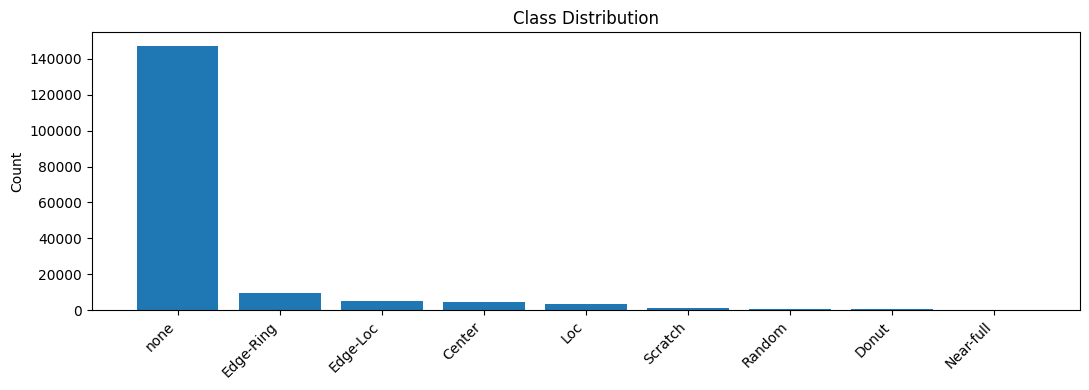

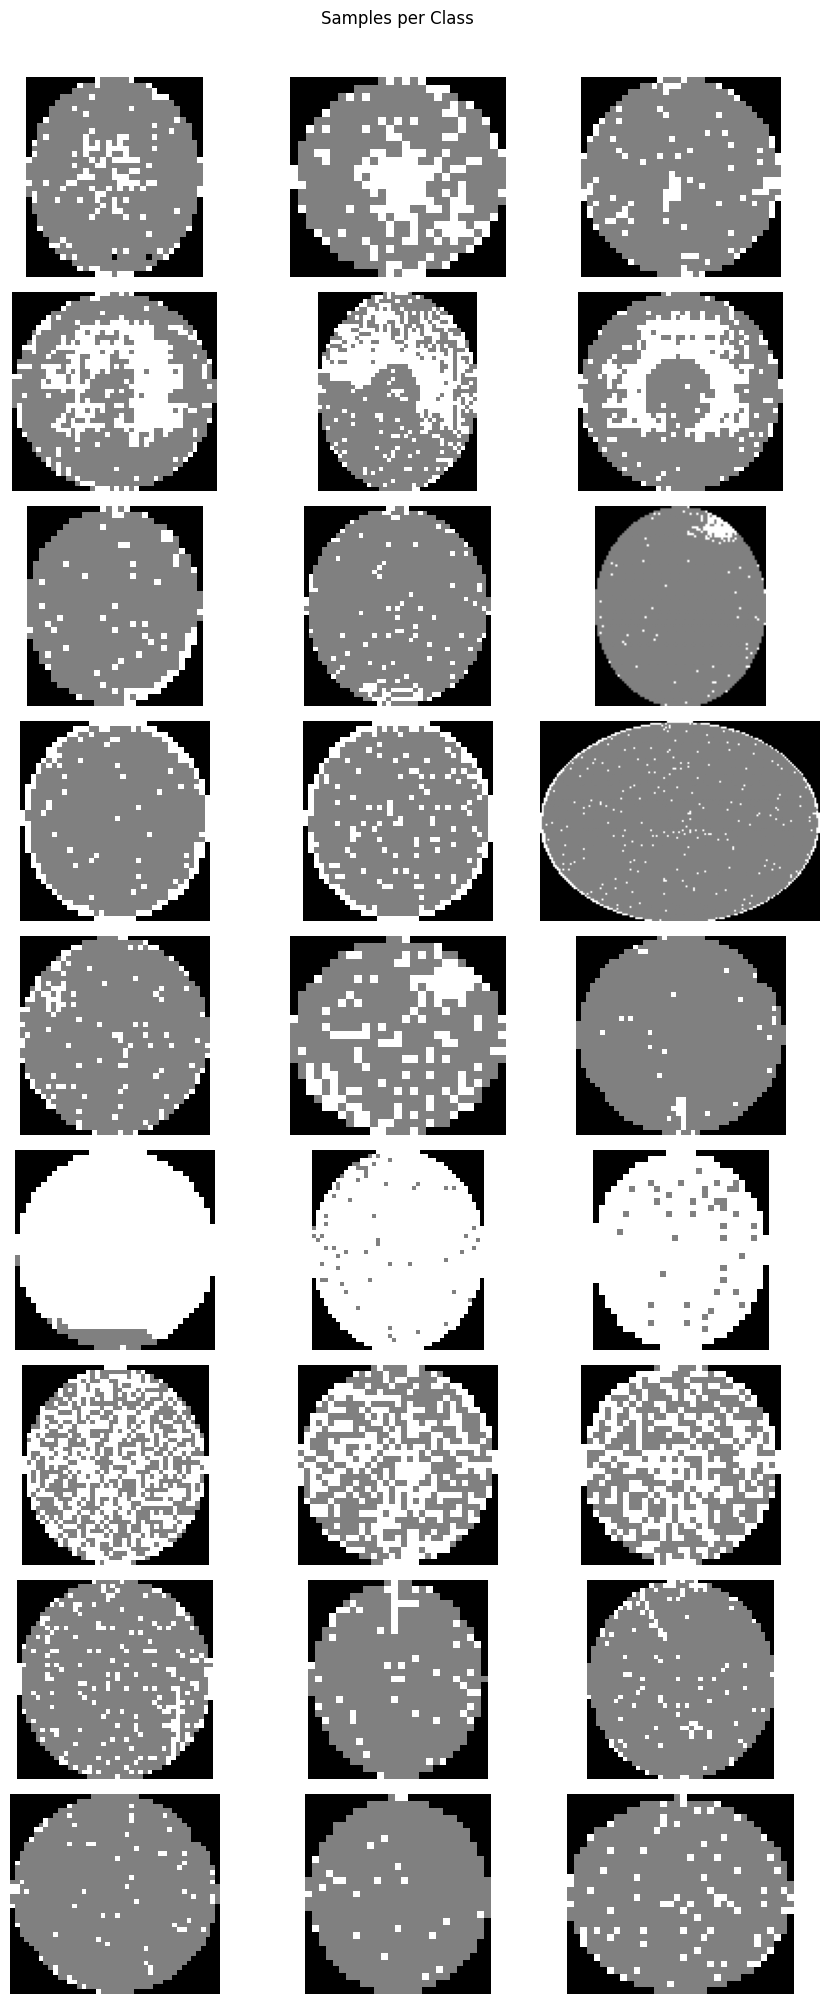

In [92]:
counts = df['_label'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(11, 4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.tight_layout(); plt.show()

n_per = 3
fig, axes = plt.subplots(NUM_CLASSES, n_per, figsize=(n_per * 3, NUM_CLASSES * 2.2))
axes = np.array(axes).reshape(NUM_CLASSES, -1) if NUM_CLASSES > 1 else np.array([axes]).reshape(1, -1)
for r, cname in enumerate(class_names):
    idxs = df.index[df['_label'] == cname].to_numpy()
    picks = np.random.choice(idxs, size=min(n_per, len(idxs)), replace=False)
    for c in range(n_per):
        ax = axes[r, c]
        if c < len(picks):
            ax.imshow(np.asarray(df.loc[picks[c], wmap_col]), cmap='gray')
            if c == 0: ax.set_ylabel(cname, fontsize=8)
        ax.axis('off')
plt.suptitle('Samples per Class', y=1.01)
plt.tight_layout(); plt.show()

## 6. Preprocessing

In [93]:
def preprocess(wmap, sz=64):
    arr = np.asarray(wmap, dtype=np.float32)
    mx = float(arr.max())
    if mx > 0:
        arr /= mx
    t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=(sz, sz), mode='nearest')
    return t.squeeze().numpy()

_s = preprocess(df.iloc[0][wmap_col], CFG['image_size'])
print('Preprocessed shape:', _s.shape, 'range:', round(float(_s.min()), 3), 'to', round(float(_s.max()), 3))

Preprocessed shape: (64, 64) range: 0.0 to 1.0


## 7. Train / Validation / Test Split

In [94]:
y_all = df['label_idx'].values
idx   = np.arange(len(df))

val_frac = CFG['val_ratio'] / (CFG['train_ratio'] + CFG['val_ratio'])

idx_tv, idx_test = train_test_split(idx, test_size=CFG['test_ratio'], stratify=y_all, random_state=CFG['seed'])
idx_tr, idx_val  = train_test_split(idx_tv, test_size=val_frac, stratify=y_all[idx_tv], random_state=CFG['seed'])

print(f'Train: {len(idx_tr):,}  Val: {len(idx_val):,}  Test: {len(idx_test):,}')

def _prop(idxs):
    return df.iloc[idxs]['_label'].value_counts(normalize=True).round(3)
display(pd.DataFrame({'train': _prop(idx_tr), 'val': _prop(idx_val), 'test': _prop(idx_test)}).fillna(0))

Train: 103,770  Val: 34,590  Test: 34,590


,train,val,test
_label,,,
none,0.852,0.852,0.852
Edge-Ring,0.056,0.056,0.056
Edge-Loc,0.030,0.030,0.030
Center,0.025,0.025,0.025
Loc,0.021,0.021,0.021
Scratch,0.007,0.007,0.007
Random,0.005,0.005,0.005
Donut,0.003,0.003,0.003
Near-full,0.001,0.001,0.001


## 8. Augmentation

In [95]:
class WaferAug:
    def __call__(self, x):
        if np.random.rand() < 0.6:
            if np.random.rand() < 0.5: x = x[:, ::-1].copy()
            if np.random.rand() < 0.5: x = x[::-1, :].copy()
        if np.random.rand() < 0.75:
            x = np.rot90(x, np.random.choice([1, 2, 3])).copy()
        if np.random.rand() < 0.3:
            dy, dx = np.random.randint(-2, 3, size=2)
            x = np.roll(np.roll(x, dy, axis=0), dx, axis=1)
        if np.random.rand() < 0.3:
            x = np.clip(x + np.random.normal(0, 0.015, x.shape).astype(np.float32), 0, 1)
        if np.random.rand() < 0.3:
            h, w = x.shape
            ch, cw = max(1, int(h * 0.15)), max(1, int(w * 0.15))
            y0 = np.random.randint(0, max(1, h - ch + 1))
            x0 = np.random.randint(0, max(1, w - cw + 1))
            x[y0:y0 + ch, x0:x0 + cw] = 0.0
        return x

aug = WaferAug()
print('Augmentation ready')

Augmentation ready


## 9. Class Imbalance

In [96]:
tr_labels  = df.iloc[idx_tr]['label_idx'].values
cls_counts = np.bincount(tr_labels, minlength=NUM_CLASSES).astype(float)
cls_w_np   = 1.0 / np.maximum(cls_counts, 1)
cls_w_np   = cls_w_np * (NUM_CLASSES / cls_w_np.sum())
cls_w_t    = torch.tensor(cls_w_np, dtype=torch.float32, device=device)

sample_w = cls_w_np[tr_labels]
sampler  = WeightedRandomSampler(
    torch.as_tensor(sample_w, dtype=torch.double),
    num_samples=len(sample_w), replacement=True
)
print('Class weights:', np.round(cls_w_np, 3))

Class weights: [1.850e-01 1.429e+00 1.530e-01 8.200e-02 2.210e-01 5.346e+00 9.150e-01
 6.650e-01 5.000e-03]


## 10. Dataset and DataLoaders

In [97]:
class WaferDS(Dataset):
    def __init__(self, df, indices, sz, aug=None):
        self.df   = df
        self.idx  = np.asarray(indices)
        self.sz   = sz
        self.aug  = aug

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        row = self.df.iloc[int(self.idx[i])]
        arr = preprocess(row[wmap_col], self.sz)
        if self.aug:
            arr = self.aug(arr)
        x = torch.from_numpy(arr).float().unsqueeze(0).repeat(3, 1, 1)
        if CFG['use_imagenet_norm']:
            mean = torch.tensor([0.485, 0.456, 0.406], dtype=x.dtype).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225], dtype=x.dtype).view(3, 1, 1)
            x = (x - mean) / std
        y = torch.tensor(int(row['label_idx']), dtype=torch.long)
        return x, y

sz     = CFG['image_size']
tr_ds  = WaferDS(df, idx_tr,   sz, aug=aug)
val_ds = WaferDS(df, idx_val,  sz, aug=None)
te_ds  = WaferDS(df, idx_test, sz, aug=None)

tr_dl  = DataLoader(tr_ds,  CFG['batch_size'], sampler=sampler if CFG['use_weighted_sampler'] else None, shuffle=not CFG['use_weighted_sampler'], num_workers=CFG['num_workers'], pin_memory=(device.type == 'cuda'))
val_dl = DataLoader(val_ds, CFG['batch_size'], shuffle=False,   num_workers=CFG['num_workers'], pin_memory=(device.type == 'cuda'))
te_dl  = DataLoader(te_ds,  CFG['batch_size'], shuffle=False,   num_workers=CFG['num_workers'], pin_memory=(device.type == 'cuda'))

xb, yb = next(iter(tr_dl))
print('Batch shape:', tuple(xb.shape), tuple(yb.shape))
print('Batch range:', float(xb.min()), 'to', float(xb.max()))

Batch shape: (64, 3, 64, 64) (64,)
Batch range: -2.1179039478302 to 2.640000104904175


## 11. Model: Multi-Scale SE-ResNet

Backbone: pre-trained ResNet34 with ImageNet weights.

Features are extracted after each of the four residual stages (64, 128, 256, 512 channels). Each scale output passes through a Squeeze-and-Excitation channel attention block, then global average pooling. The four pooled vectors are concatenated (960 dims total) and fed to a two-layer MLP classifier.

This differs from the other three models:
- Models 1 and 2 are plain sequential CNNs with no skip connections and no attention.
- Model 3 is a Vision Transformer that operates on patch tokens via self-attention.
- Model 4 uses a pre-trained multi-scale CNN backbone with channel-wise SE recalibration at every stage, giving the head simultaneous access to fine-grained texture (shallow) and high-level semantics (deep).

In [98]:
class SE(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        hidden = max(4, ch // r)
        self.fc = nn.Sequential(
            nn.Linear(ch, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, ch),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = F.adaptive_avg_pool2d(x, 1).flatten(1)
        return x * self.fc(w).view(x.size(0), -1, 1, 1)


class MSEResNet(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)

        self.s1 = base.layer1   # 64 ch
        self.s2 = base.layer2   # 128 ch
        self.s3 = base.layer3   # 256 ch
        self.s4 = base.layer4   # 512 ch

        self.se1 = SE(64)
        self.se2 = SE(128)
        self.se3 = SE(256)
        self.se4 = SE(512)

        self.head = nn.Sequential(
            nn.Linear(64 + 128 + 256 + 512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

        self.target_layer = self.s4[1].conv2  # for Grad-CAM

    def forward(self, x):
        x = self.stem(x)

        f1 = self.se1(self.s1(x))
        f2 = self.se2(self.s2(f1))
        f3 = self.se3(self.s3(f2))
        f4 = self.se4(self.s4(f3))

        p = torch.cat([
            F.adaptive_avg_pool2d(f1, 1).flatten(1),
            F.adaptive_avg_pool2d(f2, 1).flatten(1),
            F.adaptive_avg_pool2d(f3, 1).flatten(1),
            F.adaptive_avg_pool2d(f4, 1).flatten(1),
        ], dim=1)

        return self.head(p)


model = MSEResNet(num_classes=NUM_CLASSES, dropout=CFG['dropout']).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 21,826,885


## 12. Loss

In [99]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, weight=None, smoothing=0.05):
        super().__init__()
        self.gamma    = gamma
        self.weight   = weight
        self.smoothing = smoothing

    def forward(self, logits, target):
        n = logits.size(1)
        smooth = torch.full_like(logits, self.smoothing / (n - 1))
        smooth.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        log_p = F.log_softmax(logits, dim=1)
        ce    = -(smooth * log_p).sum(dim=1)
        pt    = torch.exp(-F.cross_entropy(logits, target, weight=self.weight, reduction='none'))
        return (((1 - pt) ** self.gamma) * ce).mean()

if CFG['loss_name'] == 'weighted_ce':
    criterion = nn.CrossEntropyLoss(weight=cls_w_t, label_smoothing=CFG['label_smooth'])
elif CFG['loss_name'] == 'ce':
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])
else:
    criterion = FocalLoss(gamma=1.0, weight=cls_w_t, smoothing=CFG['label_smooth'])
print('Criterion:', criterion)

Criterion: CrossEntropyLoss()


## 13. Training

In [100]:
class EarlyStopper:
    def __init__(self, patience):
        self.patience = patience
        self.best = -1.0
        self.wait = 0
        self.stop = False

    def step(self, val):
        if val > self.best:
            self.best, self.wait = val, 0
            return True
        self.wait += 1
        if self.wait >= self.patience:
            self.stop = True
        return False


def run_epoch(model, loader, crit, opt=None, scaler=None):
    training = opt is not None
    model.train(training)
    total_loss, yt, yp = 0.0, [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        if training:
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(scaler is not None)):
                logits = model(xb)
                loss = crit(logits, yb)
            if not torch.isfinite(logits).all():
                raise RuntimeError('Non-finite logits detected during training')
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite loss detected during training')
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                opt.step()
        else:
            with torch.no_grad():
                logits = model(xb)
                loss = crit(logits, yb)
            if not torch.isfinite(logits).all():
                raise RuntimeError('Non-finite logits detected during validation')
            if not torch.isfinite(loss):
                raise RuntimeError('Non-finite loss detected during validation')
        total_loss += loss.item() * yb.size(0)
        yp.extend(logits.argmax(1).cpu().numpy())
        yt.extend(yb.cpu().numpy())
    n = len(yt)
    return total_loss / n, accuracy_score(yt, yp), f1_score(yt, yp, average='macro', zero_division=0)


backbone_params = (list(model.stem.parameters()) + list(model.s1.parameters()) +
                   list(model.s2.parameters()) + list(model.s3.parameters()) +
                   list(model.s4.parameters()))
head_params = (list(model.se1.parameters()) + list(model.se2.parameters()) +
               list(model.se3.parameters()) + list(model.se4.parameters()) +
               list(model.head.parameters()))

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 0.0},
    {'params': head_params,     'lr': CFG['lr']},
], weight_decay=CFG['weight_decay'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler    = torch.amp.GradScaler('cuda') if (CFG['mixed_prec'] and device.type == 'cuda') else None
stopper   = EarlyStopper(CFG['patience'])
for param in backbone_params:
    param.requires_grad = False

os.makedirs(CFG['output_dir'], exist_ok=True)
ckpt_path = os.path.join(CFG['output_dir'], 'model4_best.pt')

history    = {'tr_loss': [], 'tr_acc': [], 'va_loss': [], 'va_acc': [], 'va_f1': [], 'lr': []}
best_state = None
t0         = time.time()

for ep in range(1, CFG['epochs'] + 1):
    ep_t0 = time.time()
    if ep == CFG['freeze_backbone_epochs'] + 1:
        for param in backbone_params:
            param.requires_grad = True
        optimizer.param_groups[0]['lr'] = CFG['lr_backbone']
        print('Unfroze backbone.')
    tr_loss, tr_acc, _     = run_epoch(model, tr_dl, criterion, optimizer, scaler)
    va_loss, va_acc, va_f1 = run_epoch(model, val_dl, criterion)
    scheduler.step()
    lr_now = optimizer.param_groups[1]['lr']

    for k, v in zip(history, [tr_loss, tr_acc, va_loss, va_acc, va_f1, lr_now]):
        history[k].append(v)

    saved = stopper.step(va_f1)
    if saved:
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, ckpt_path)

    suffix = '  *' if saved else ''
    print(
        f'epoch {ep:2d} | '
        f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
        f'val loss {va_loss:.4f} acc {va_acc:.4f} f1 {va_f1:.4f} | '
        f'lr {lr_now:.2e} | '
        f'{time.time() - ep_t0:.1f}s{suffix}'
    )
    if stopper.stop:
        print(f'Early stop at epoch {ep}.')
        break

if best_state:
    model.load_state_dict(best_state)
print(f'\nDone in {time.time() - t0:.1f}s | best val macro-F1 {stopper.best:.4f}')

epoch  1 | train loss 1.3349 acc 0.5842 | val loss 1.0417 acc 0.6999 f1 0.4395 | lr 9.99e-05 | 249.7s  *
epoch  2 | train loss 1.0823 acc 0.6802 | val loss 0.9480 acc 0.7416 f1 0.4978 | lr 9.96e-05 | 278.5s  *
epoch  3 | train loss 1.0150 acc 0.7145 | val loss 0.8870 acc 0.7707 f1 0.5236 | lr 9.91e-05 | 273.6s  *
Unfroze backbone.
epoch  4 | train loss 0.8530 acc 0.7761 | val loss 0.6607 acc 0.8550 f1 0.6348 | lr 9.84e-05 | 324.2s  *
epoch  5 | train loss 0.6583 acc 0.8601 | val loss 0.5260 acc 0.9175 f1 0.7071 | lr 9.76e-05 | 330.3s  *
epoch  6 | train loss 0.5630 acc 0.8973 | val loss 0.4491 acc 0.9249 f1 0.7356 | lr 9.65e-05 | 354.6s  *
epoch  7 | train loss 0.5139 acc 0.9103 | val loss 0.4365 acc 0.9288 f1 0.7582 | lr 9.52e-05 | 316.2s  *
epoch  8 | train loss 0.4510 acc 0.9269 | val loss 0.4381 acc 0.9423 f1 0.7878 | lr 9.38e-05 | 341.2s  *
epoch  9 | train loss 0.4412 acc 0.9309 | val loss 0.3852 acc 0.9391 f1 0.7745 | lr 9.22e-05 | 337.6s
epoch 10 | train loss 0.3876 acc 0.9376 

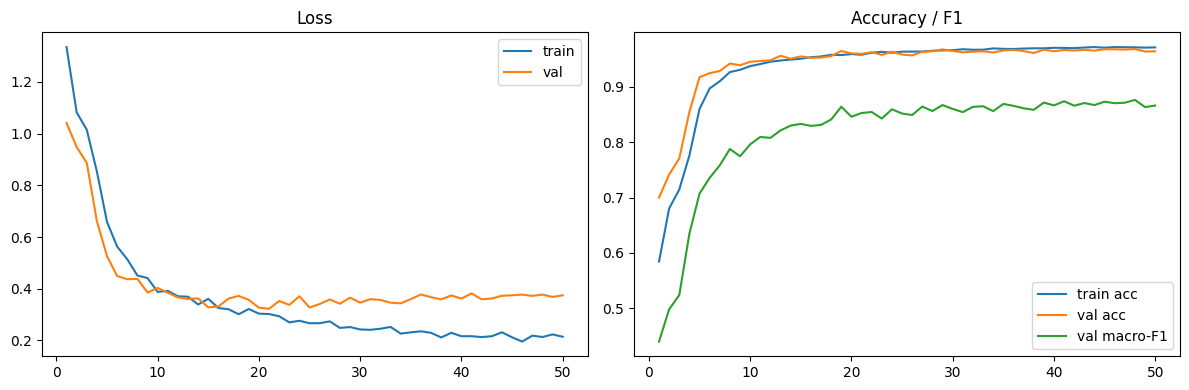

In [101]:
eps = range(1, len(history['tr_loss']) + 1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(eps, history['tr_loss'], label='train'); a1.plot(eps, history['va_loss'], label='val')
a1.set_title('Loss'); a1.legend()
a2.plot(eps, history['tr_acc'],  label='train acc')
a2.plot(eps, history['va_acc'],  label='val acc')
a2.plot(eps, history['va_f1'],   label='val macro-F1')
a2.set_title('Accuracy / F1'); a2.legend()
plt.tight_layout(); plt.show()

## 14. Test Evaluation

In [102]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    yt, yp = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yp.extend(model(xb).argmax(1).cpu().numpy())
        yt.extend(yb.numpy())
    return np.array(yt), np.array(yp)


y_true, y_pred = predict(model, te_dl)

metrics = {
    'accuracy': accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'kappa': cohen_kappa_score(y_true, y_pred),
    'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    'weighted_precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
    'weighted_recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
    'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
}

print(f'Test samples: {len(y_true):,}')
print(f"\nAccuracy:           {metrics['accuracy']:.4f}")
print(f"Balanced accuracy:  {metrics['balanced_accuracy']:.4f}  (mean per-class recall)")
print(f"Cohen's kappa:      {metrics['kappa']:.4f}")
for avg in ('macro', 'weighted'):
    p = metrics[f'{avg}_precision']
    r = metrics[f'{avg}_recall']
    f = metrics['f1_macro'] if avg == 'macro' else metrics['f1_weighted']
    print(f"{avg:>8s}: precision {p:.4f}  recall {r:.4f}  f1 {f:.4f}")

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

Test samples: 34,590

Accuracy:           0.9679
Balanced accuracy:  0.9039  (mean per-class recall)
Cohen's kappa:      0.8849
   macro: precision 0.8318  recall 0.9039  f1 0.8652
weighted: precision 0.9708  recall 0.9679  f1 0.9690

Per-class report:
              precision    recall  f1-score   support

      Center     0.8711    0.9360    0.9024       859
       Donut     0.8167    0.8829    0.8485       111
    Edge-Loc     0.7540    0.8536    0.8007      1038
   Edge-Ring     0.9553    0.9835    0.9692      1936
         Loc     0.6912    0.7855    0.7353       718
   Near-full     0.9355    0.9667    0.9508        30
      Random     0.8333    0.9249    0.8767       173
     Scratch     0.6355    0.8243    0.7177       239
        none     0.9934    0.9780    0.9856     29486

    accuracy                         0.9679     34590
   macro avg     0.8318    0.9039    0.8652     34590
weighted avg     0.9708    0.9679    0.9690     34590



## 15. Per-Class Metrics and Confusion Matrix

,class,precision,recall,f1,support
0,none,0.993352,0.977990,0.985611,29486
1,Edge-Ring,0.955344,0.983471,0.969203,1936
2,Near-full,0.935484,0.966667,0.950820,30
3,Center,0.871073,0.935972,0.902357,859
4,Random,0.833333,0.924855,0.876712,173
5,Donut,0.816667,0.882883,0.848485,111
6,Edge-Loc,0.754043,0.853565,0.800723,1038
7,Loc,0.691176,0.785515,0.735332,718
8,Scratch,0.635484,0.824268,0.717668,239


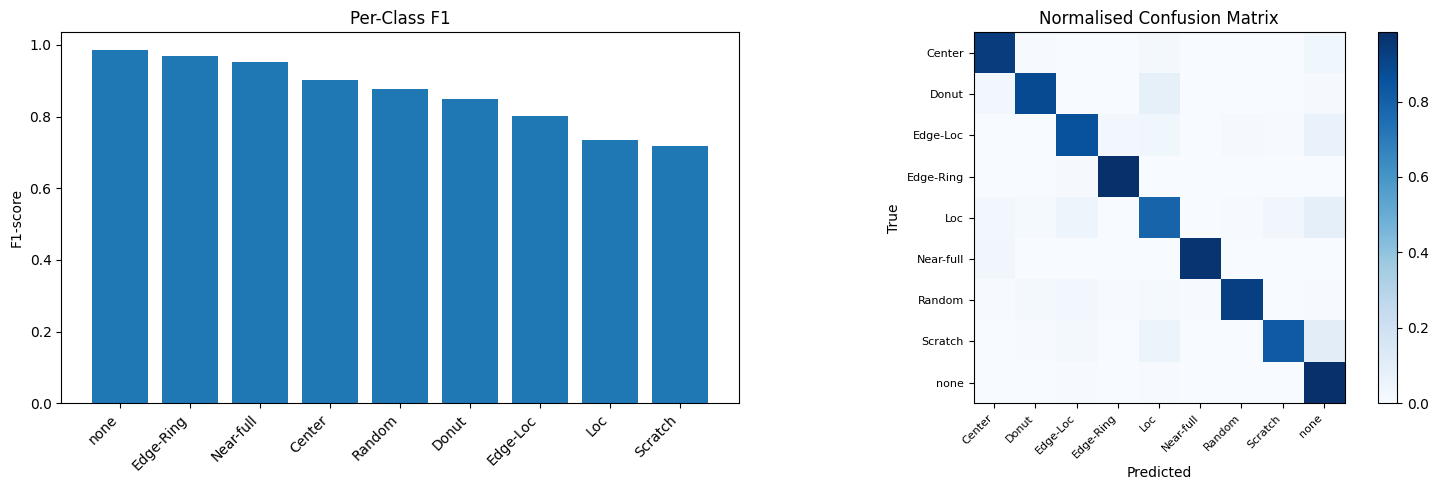

In [103]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
per_cls = pd.DataFrame([
    {'class': c, 'precision': report[c]['precision'],
     'recall': report[c]['recall'], 'f1': report[c]['f1-score'],
     'support': int(report[c]['support'])}
    for c in class_names if c in report
]).sort_values('f1', ascending=False).reset_index(drop=True)
display(per_cls)

cm   = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_n = cm.astype(float) / np.maximum(cm.sum(1, keepdims=True), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
xp = np.arange(len(per_cls))
ax1.bar(xp, per_cls['f1'])
ax1.set_xticks(xp); ax1.set_xticklabels(per_cls['class'], rotation=45, ha='right')
ax1.set_ylabel('F1-score'); ax1.set_title('Per-Class F1')

im = ax2.imshow(cm_n, cmap='Blues')
ax2.set_xticks(range(NUM_CLASSES)); ax2.set_yticks(range(NUM_CLASSES))
ax2.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(class_names, fontsize=8)
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')
ax2.set_title('Normalised Confusion Matrix')
plt.colorbar(im, ax=ax2)
plt.tight_layout(); plt.show()

## 16. Error Analysis

Correct: 33,479  |  Wrong: 1,111


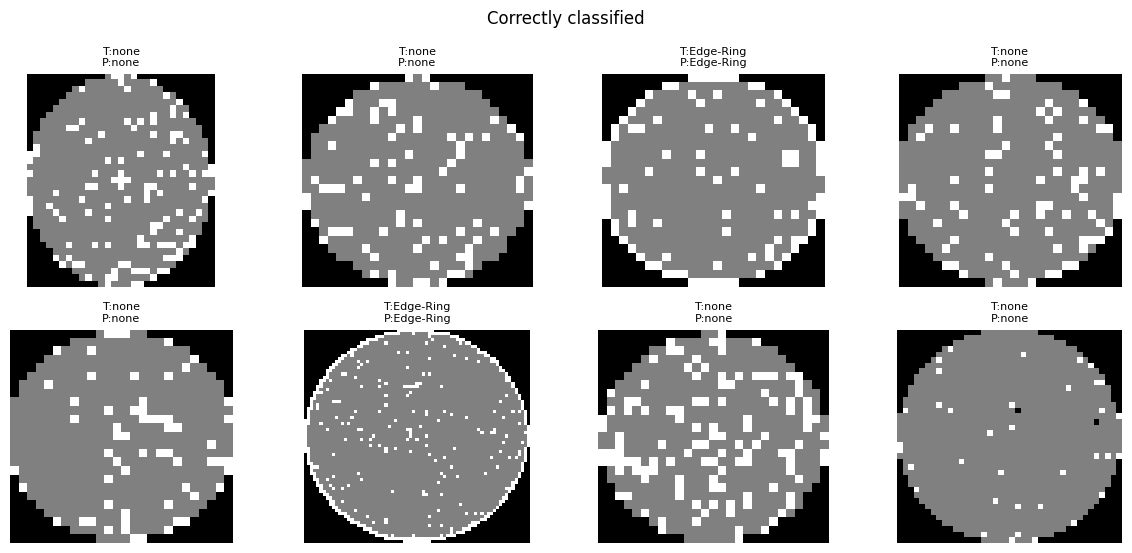

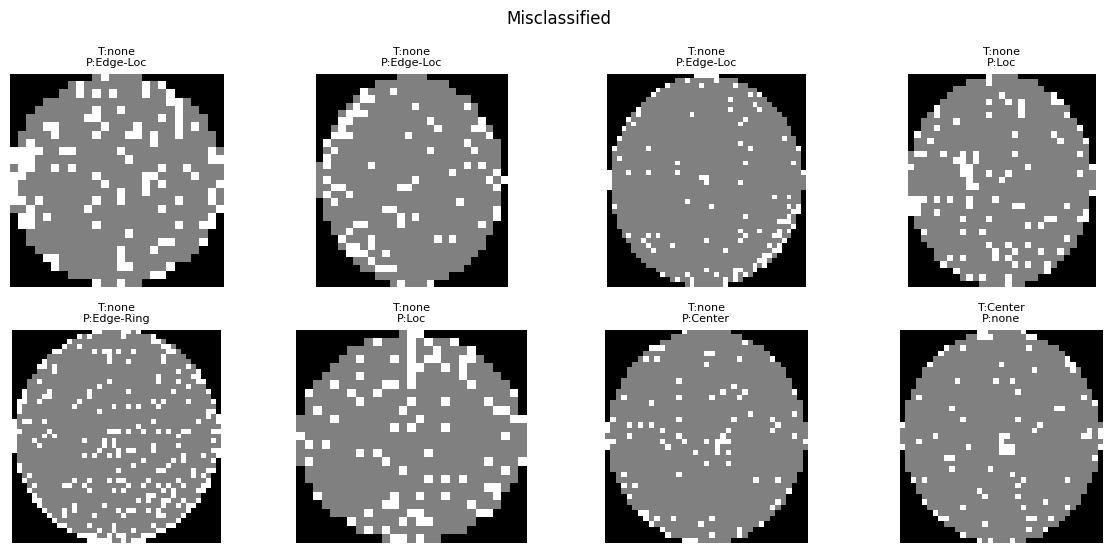


Top confusion pairs:
  Center -> none: 30
  Donut -> Loc: 9
  Edge-Loc -> none: 69
  Edge-Ring -> Edge-Loc: 22
  Loc -> none: 61
  Near-full -> Center: 1
  Random -> Edge-Loc: 4
  Scratch -> none: 24
  none -> Edge-Loc: 221


In [104]:
@torch.no_grad()
def predict_ordered(model, ds, bs=128):
    model.eval()
    dl = DataLoader(ds, bs, shuffle=False, num_workers=CFG['num_workers'])
    preds = []
    for xb, _ in dl:
        preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
    return np.array(preds, dtype=int)

te_true = df.iloc[idx_test]['label_idx'].values
te_pred = predict_ordered(model, te_ds)
correct = te_true == te_pred
print(f'Correct: {correct.sum():,}  |  Wrong: {(~correct).sum():,}')

def show_samples(mask, title, n=8):
    idxs = np.where(mask)[0]
    if not len(idxs): return
    picks = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)
    nc = 4; nr = math.ceil(len(picks) / nc)
    fig, axes = plt.subplots(nr, nc, figsize=(nc * 3, nr * 2.8))
    axes = np.array(axes).reshape(-1)
    for i, loc in enumerate(picks):
        gi = idx_test[loc]
        axes[i].imshow(np.asarray(df.iloc[gi][wmap_col]), cmap='gray')
        axes[i].set_title(f'T:{idx2cls[te_true[loc]]}\nP:{idx2cls[te_pred[loc]]}', fontsize=8)
        axes[i].axis('off')
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()

show_samples(correct,  'Correctly classified', n=8)
show_samples(~correct, 'Misclassified', n=8)

print('\nTop confusion pairs:')
cm_e = confusion_matrix(te_true, te_pred, labels=list(range(NUM_CLASSES)))
for i in range(NUM_CLASSES):
    row = cm_e[i].copy(); row[i] = 0; j = row.argmax()
    if row[j] > 0:
        print(f'  {idx2cls[i]} -> {idx2cls[j]}: {int(row[j])}')

## 17. Grad-CAM

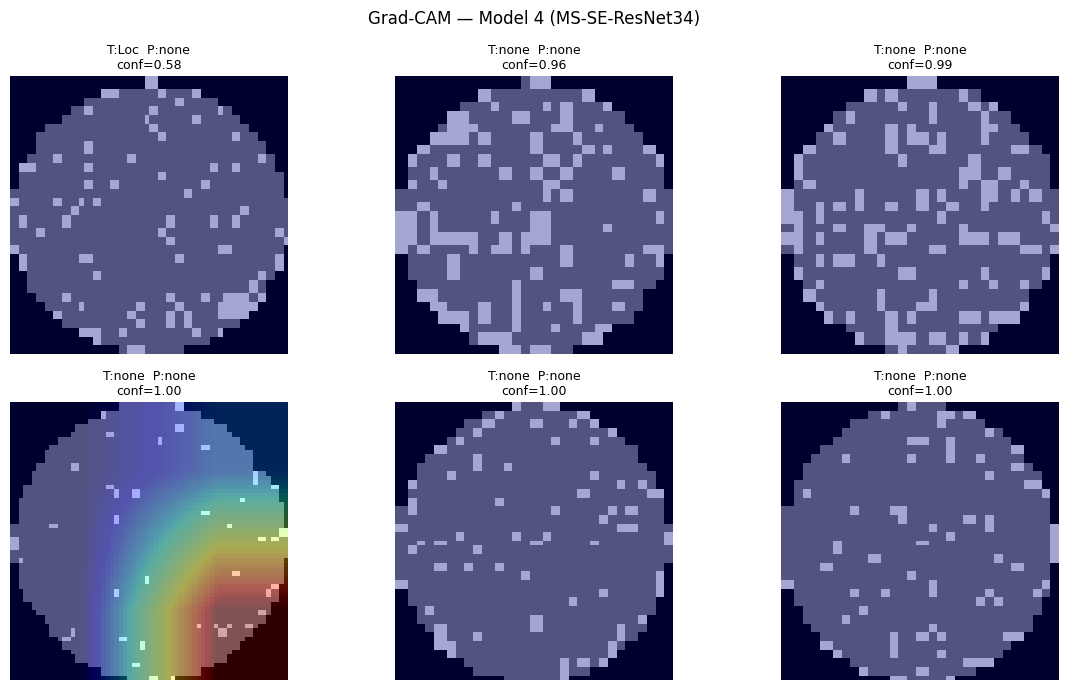

In [105]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self._acts = None
        self._grads = None
        self._h1 = layer.register_forward_hook(lambda m, i, o: setattr(self, '_acts', o.detach()))
        self._h2 = layer.register_full_backward_hook(lambda m, i, o: setattr(self, '_grads', o[0].detach()))

    def __call__(self, x, cls=None):
        self.model.eval()
        logits = self.model(x)
        cls = cls if cls is not None else int(logits.argmax(1))
        self.model.zero_grad(set_to_none=True)
        logits[:, cls].sum().backward(retain_graph=True)
        w   = self._grads.mean((2, 3), keepdim=True)
        cam = F.relu((w * self._acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        probs = torch.softmax(logits, 1).detach().cpu().numpy()[0]
        return cam, cls, probs

    def close(self):
        self._h1.remove(); self._h2.remove()


gcam  = GradCAM(model, model.target_layer)
picks = np.random.choice(len(te_ds), size=6, replace=False)
cols  = 3; rows = math.ceil(len(picks) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = np.array(axes).reshape(-1)

for i, li in enumerate(picks):
    x, y = te_ds[li]
    cam, pred, probs = gcam(x.unsqueeze(0).to(device))
    axes[i].imshow(x[0].numpy(), cmap='gray')
    axes[i].imshow(cam, cmap='jet', alpha=0.35)
    axes[i].set_title(f'T:{idx2cls[int(y)]}  P:{idx2cls[pred]}\nconf={probs[pred]:.2f}', fontsize=9)
    axes[i].axis('off')

for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.suptitle('Grad-CAM — Model 4 (MS-SE-ResNet34)')
plt.tight_layout(); plt.show()
gcam.close()

## 18. Save Results

In [106]:
out = Path(CFG['output_dir']); out.mkdir(exist_ok=True)

pd.DataFrame([metrics]).to_csv(out / 'model4_metrics.csv', index=False)
per_cls.to_csv(out / 'model4_per_class_f1.csv', index=False)

pd.DataFrame(classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
)).transpose().to_csv(out / 'model4_classification_report.csv')

with open(out / 'model4_classification_report.txt', 'w') as f:
    f.write(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

fig_cm, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_n, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Model 4 — Confusion Matrix')
plt.colorbar(im, ax=ax); plt.tight_layout()
fig_cm.savefig(out / 'model4_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.close(fig_cm)

pd.Series(CFG, dtype='object').to_csv(out / 'model4_config.csv')
print('Saved to', out)
for p in sorted(out.iterdir()): print(' ', p.name)

Saved to outputs_model4
  model4_best.pt
  model4_classification_report.csv
  model4_classification_report.txt
  model4_config.csv
  model4_confusion_matrix.png
  model4_metrics.csv
  model4_per_class_f1.csv


## 19. Summary

**Model 4 — Multi-Scale Squeeze-and-Excitation ResNet (MS-SE-ResNet34)**

The backbone is a ResNet34 pre-trained on ImageNet. Instead of only using the final feature map, this model taps into all four residual stages and applies a channel-wise SE attention block to each before global average pooling. The four pooled vectors (64 + 128 + 256 + 512 = 960 dims) are concatenated and passed through a two-layer MLP.

Key training decisions:
- Differential LRs: backbone at 1e-5 (fine-tuning existing weights), SE gates and classifier at 3e-4 (learning from scratch)
- Focal loss with label smoothing to handle class imbalance and reduce overconfidence
- WeightedRandomSampler for balanced per-epoch class exposure
- Cosine LR annealing with early stopping on validation macro-F1

Comparison with the other models:

| Model | Core idea |
|-------|-----------|
| 1 | Sequential CNN with BN (no attention, no skip connections) |
| 2 | Same architecture as Model 1, different training setup |
| 3 | Vision Transformer (patch embedding + multi-head self-attention) |
| 4 | Pre-trained ResNet34 + multi-scale SE attention fusion |

The multi-scale design is the key distinction: early stages capture fine defect texture while deep stages carry semantic class information, and SE recalibration at each stage lets the network suppress uninformative channels before pooling.